# Prepare Environment

In [1]:
!python --version
!pip --version
!python -m pip install --upgrade pip
!pip install pandas scikit-learn matplotlib seaborn

Python 3.12.2
pip 26.1.2 from C:\Users\saman\IdeaProjects\python-tutorial\.venv\Lib\site-packages\pip (python 3.12)



In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


# Read Data

In [3]:
df = pd.read_csv("housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [6]:
df.count()

longitude             20433
latitude              20433
housing_median_age    20433
total_rooms           20433
total_bedrooms        20433
population            20433
households            20433
median_income         20433
median_house_value    20433
ocean_proximity       20433
dtype: int64

# Clean Data


In [8]:
df = df.dropna(subset=["total_bedrooms"])
total_bedrooms_median = df["total_bedrooms"].median()
df = df.fillna({"total_bedrooms": total_bedrooms_median})

In [9]:
df.count()

longitude             20433
latitude              20433
housing_median_age    20433
total_rooms           20433
total_bedrooms        20433
population            20433
households            20433
median_income         20433
median_house_value    20433
ocean_proximity       20433
dtype: int64

# Splitting Data

In [12]:
train, test = train_test_split(df, test_size=0.2, random_state=40)
print(f"Train No: {len(train)},\nTest No: {len(test)}")

Train No: 16346,
Test No: 4087


In [13]:
train.corr(numeric_only=True)[["median_house_value"]]

,median_house_value
longitude,-0.046008
latitude,-0.144145
housing_median_age,0.106377
total_rooms,0.132473
total_bedrooms,0.046652
population,-0.025933
households,0.063247
median_income,0.689272
median_house_value,1.000000


# Visualization

Text(0.5, 1.0, 'Housing Price')

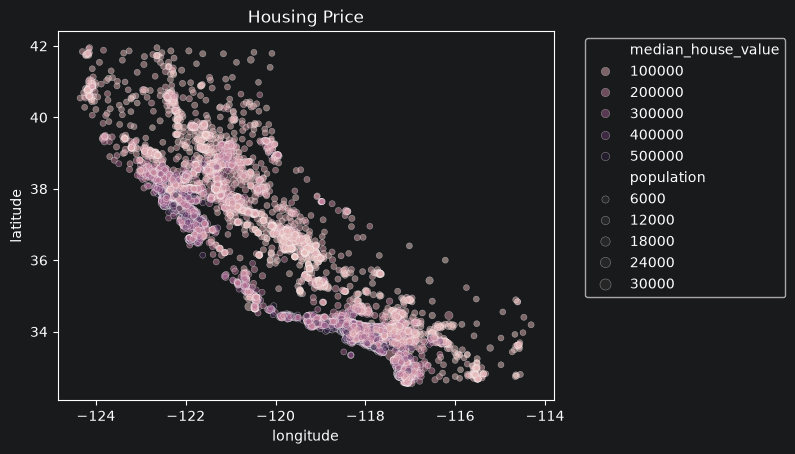

In [14]:
ax = sns.scatterplot(data=train, x="longitude", y="latitude", size="population", alpha=0.5, hue="median_house_value")
sns.move_legend(obj=ax, loc="upper left", bbox_to_anchor=(1.05, 1))
ax.set_title("Housing Price")

<Axes: xlabel='median_income', ylabel='median_house_value'>

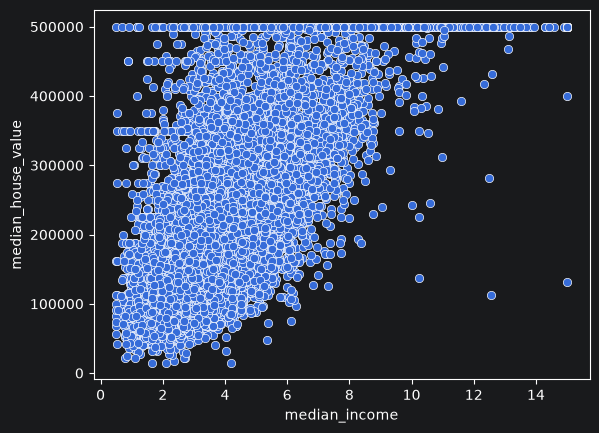

In [15]:
sns.scatterplot(data=train, x="median_income", y="median_house_value")

In [23]:
scaler = StandardScaler()
train[["median_house_value"]] = scaler.fit_transform(train[["median_house_value"]])

model = LinearRegression()
model.fit(train[["median_income"]], train["median_house_value"])
model.predict(train[["median_income"]])

array([-0.74367718,  0.07705537, -0.62367629, ..., -0.23096251,
        0.08137843, -0.60292561], shape=(16346,))